In [ ]:
# Imports and Setup

from glass_dynamics.core.logger import logger

from glass_dynamics.data.processor import filter_and_fit_dataset
from glass_dynamics.data.composition import gen_atomic_df
from glass_dynamics.data.splitting import split_by_cassar_indices, split_by_random_seed

from glass_dynamics.features.generator import generate_all_features, generate_cassar_35_features
from glass_dynamics.features.correlation import select_features_from_clusters
from glass_dynamics.features.vif import calculate_vif, calculate_ridge_vif, iterative_vif_selection, fast_iterative_vif_selection

from glass_dynamics.analysis.performance import compute_alpha_performance_metrics
from glass_dynamics.analysis.traces import compute_weight_traces
from glass_dynamics.analysis.feature_importance_old import extract_importance
from glass_dynamics.analysis.evolution import extract_top_features_evolution
from glass_dynamics.analysis.extrapolation import generate_extrapolation_metrics
from glass_dynamics.analysis.myega_bootstrap import generate_bootstrap_predictions

from glass_dynamics.visualization.features_exploration_plots import plot_pearson_correlation, generate_feature_metadata_table
from glass_dynamics.visualization.performance_plots import plot_target_performance
from glass_dynamics.visualization.traces_plots import plot_normalized_traces
from glass_dynamics.visualization.importance_plots import plot_sorted_feature_importance
from glass_dynamics.visualization.evolution_plots import plot_top_features_evolution
from glass_dynamics.visualization.density_plots import plot_viscosity_density_correlation
from glass_dynamics.visualization.distance_plots import plot_rmse_vs_distance_square
from glass_dynamics.visualization.viscosity_grids import plot_viscosity_grids_bootstrap

from glass_dynamics.models.ridge import CustomRidgeRegression

from glass_dynamics.evaluation.model_evaluation import evaluate_final_model

from glass_dynamics.utils.naming import generate_glass_names

import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from pathlib import Path
import pickle


analysis_name = "ols_base_VIF10"

data_path = Path(f"../../data/cassar_split/base_analysis")
plots_path = Path(f"../../plots/ols/{analysis_name}")
model_path = Path(f"../../models/ols/{analysis_name}")
plots_path.mkdir(parents=True, exist_ok=True)
data_path.mkdir(parents=True, exist_ok=True)
model_path.mkdir(parents=True, exist_ok=True)


In [46]:
# Data Loading
logger.info("Loading raw datasets...")

raw_data = pd.read_csv('../../data/viscosity_raw_data.csv', index_col=0) 
chemical_props_T = pd.read_csv("../../data/chemical_properties.csv", index_col=0).T
chemical_props = pd.read_csv("../../data/chemical_properties.csv", index_col=0)
# raw_data


[INFO] 2026-09-22 12:18:10 - Loading raw datasets...


In [47]:
# MYEGA Fit and Filter
clean_glasses_df, rejected_glasses_df = filter_and_fit_dataset(raw_data, min_r2_threshold=0.95)
y_targets = clean_glasses_df[['ID', 'Tg_fitted', 'm_fitted', 'log_eta_inf_fitted']].set_index('ID')
oxides_df = clean_glasses_df.drop(columns=['Tg_fitted', 'm_fitted', 'log_eta_inf_fitted', 'myega_r2', 'myega_rmse']).set_index('ID')
# oxides_df


[INFO] 2026-09-22 12:18:10 - Starting data processing and MYEGA fitting on 847 unique glasses...
[INFO] 2026-09-22 12:18:32 - Processing complete. Accepted glasses: 847. Rejected glasses: 0.


In [48]:
# Convert Oxides to Elements
atomic_df = gen_atomic_df(oxides_df, chemical_props_T)
# atomic_df


[INFO] 2026-09-22 12:18:32 - Converting compound fractions to elemental atomic fractions using chemparse...
[INFO] 2026-09-22 12:18:32 - Successfully converted. Output shape: (847, 59)


In [49]:
# # Generate cassar viscnet features
# X_cassar_features = generate_cassar_35_features(atomic_df, chemical_props)
# X_cassar_features

In [50]:
# This generates 560 features
X_all_features = generate_all_features(atomic_df, chemical_props)
# X_all_features


[INFO] 2026-09-22 12:18:32 - Generating all W and A features from 56 chemical properties...
[INFO] 2026-09-22 12:20:16 - Feature generation complete. Total features created: 560


In [51]:
# Data splitting
X_train, X_test, y_train, y_test = split_by_cassar_indices(X_all_features, y_targets, "../../data/cassar_split/test_ids.parquet")
# X_test

[INFO] 2026-09-22 12:20:16 - Splitting dataset using predefined indices from ../../data/cassar_split/test_ids.parquet...
[INFO] 2026-09-22 12:20:16 - Split complete. Train size: 762, Test size: 85


In [52]:
# Standardize features and output
X_scaler = StandardScaler().set_output(transform="pandas")
X_train_scaled = X_scaler.fit_transform(X_train)
X_test_scaled = X_scaler.transform(X_test)

y_scaler = StandardScaler().set_output(transform="pandas")
y_train_scaled = y_scaler.fit_transform(y_train)
y_test_scaled = y_scaler.transform(y_test)

# y_test_scaled

In [53]:
# Safety step: removing features with a low standard deviation less than 10^-3
train_std = X_train_scaled.std()
features_with_std = train_std[train_std > 1e-3].index.tolist()
X_filtered = X_train_scaled[features_with_std]

logger.info(f"Features remaining after standard deviation filter (> 10^-3): {X_filtered.shape[1]}")

[INFO] 2026-09-22 12:20:16 - Features remaining after standard deviation filter (> 10^-3): 514


In [ ]:
# Group highly correlated features and select one representative per cluster
# We use 'm_fitted' to select the feature in the cluster most correlated with the target

threshold = 0.01 # Distance threshold (meaning |correlation| > 0.99 are grouped together)
selected_cluster_features = select_features_from_clusters(X_filtered, y_targets['m_fitted'], threshold=threshold)

X_clustered = X_filtered[selected_cluster_features]

logger.info(f"Features remaining after Clustering selection: {X_clustered.shape[1]}")

[INFO] 2026-09-22 12:30:48 - Computing Spearman correlation matrix...
[INFO] 2026-09-22 12:30:48 - Computing hierarchical clustering linkage (Ward)...
[INFO] 2026-09-22 12:30:48 - Formed 333 clusters with distance threshold 0.01.
[INFO] 2026-09-22 12:30:49 - Features remaining after Clustering selection: 333


In [92]:
#!  Iterative VIF feature selection

surviving_features = fast_iterative_vif_selection(X_clustered, threshold=10.0)
X_train_final_standard = X_clustered[surviving_features]
X_test_final_standard = X_test_scaled[surviving_features]

# X_train_final_standard

[INFO] 2026-09-22 12:30:52 - Initiating fast VIF selection (threshold=10.0) on 333 features.
[INFO] 2026-09-22 12:31:05 - VIF selection converged. Maximum final VIF: 9.23
[INFO] 2026-09-22 12:31:05 - VIF selection complete. Retained 45 features.


In [93]:
# Saving data

X_train_final_standard.to_parquet(data_path / 'X_train.parquet')
X_test_final_standard.to_parquet(data_path / 'X_test.parquet')

y_train.to_parquet('../../data/cassar_split/y_train.parquet')
y_test.to_parquet('../../data/cassar_split/y_test.parquet')

,Type,Aggregator,Chemical Property
0,W,Max,GSbandgap
1,W,Max,GSvolume pa
2,W,Max,SpaceGroupNumber
3,W,Max,atomic radius
4,W,Max,atomic volume
5,W,Max,c6 gb
6,W,Max,num oxistates
7,W,Min,ElectronAffinity
8,W,Min,FusionEnthalpy
9,W,Min,NUnfilled


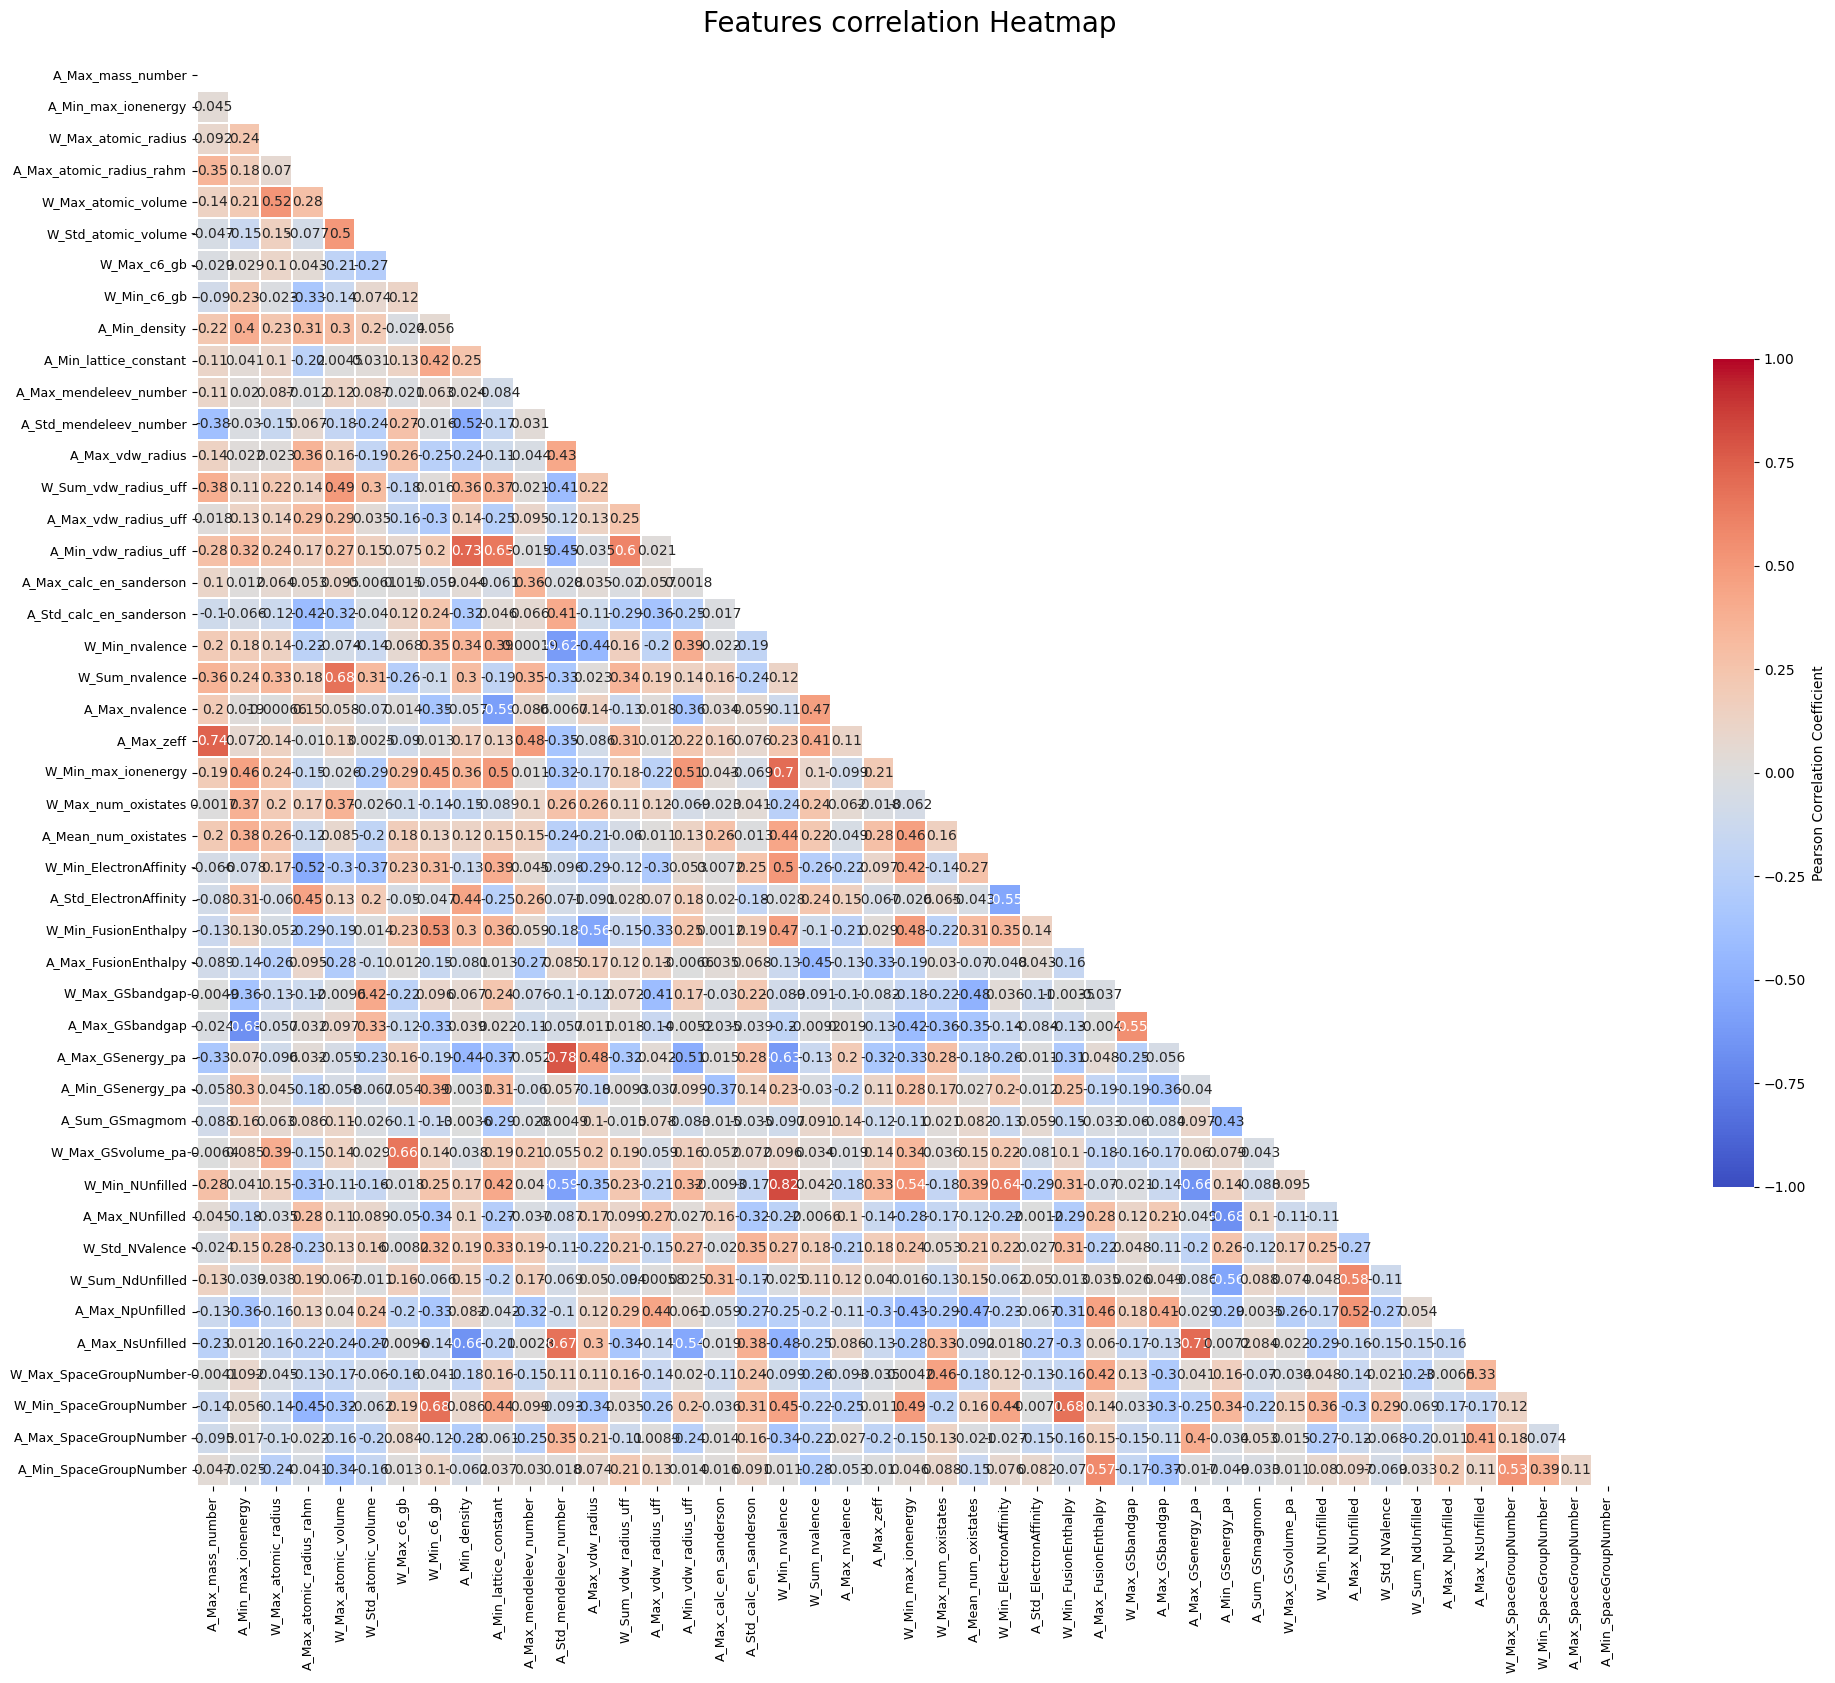

In [94]:
# Selected features visualization
corr_plot = plot_pearson_correlation(X_train_final_standard, show_numbers=True)
corr_plot.savefig(plots_path / 'correlation_matrix.pdf', bbox_inches='tight')

df_features = generate_feature_metadata_table(X_train_final_standard)
display(df_features[['Type', 'Aggregator', 'Chemical Property']])


In [95]:
# Compute Standard VIF
logger.info("Computing Standard OLS VIF on clustered features...")
X_standard_vif_df = calculate_vif(X_train_final_standard)
print("\n--- Standard OLS VIF (Top 10 Worst Features) ---")
print(X_standard_vif_df.head(40))


# Compute Ridge VIF (alpha = 0.1) to see stabilization (Sharma et al. paper)
# logger.info("Computing Ridge VIF (alpha=0,1)...")
# ridge_vif_df = calculate_ridge_vif(X_scaled, alpha=0.1)
# print("\n--- Ridge VIF alpha=0.1 (Top 10 Worst Features) ---")
# print(ridge_vif_df.head(10))

[INFO] 2026-09-22 12:31:35 - Computing Standard OLS VIF on clustered features...
[INFO] 2026-09-22 12:31:35 - Calculating standard OLS VIF for features...

--- Standard OLS VIF (Top 10 Worst Features) ---
                     Feature       VIF
0            W_Min_NUnfilled  9.228410
1            A_Max_GSbandgap  9.135615
2     A_Std_mendeleev_number  8.843218
3          A_Max_mass_number  8.469794
4                 A_Max_zeff  8.412616
5       A_Min_vdw_radius_uff  8.398636
6        A_Min_max_ionenergy  8.318321
7             W_Min_nvalence  8.225781
8             W_Sum_nvalence  7.848624
9              A_Min_density  7.416210
10         A_Max_GSenergy_pa  7.405962
11       W_Max_atomic_volume  7.396567
12          A_Max_NsUnfilled  7.124804
13    W_Min_ElectronAffinity  7.045743
14    W_Min_SpaceGroupNumber  6.895161
15           W_Max_GSbandgap  6.859027
16   A_Std_calc_en_sanderson  6.844138
17          A_Max_NpUnfilled  6.812859
18         A_Min_GSenergy_pa  6.630894
19    A_Std_Ele

[INFO] 2026-09-22 12:32:11 - Extracting raw feature importance at alpha=0.1 over 100 splits.
[INFO] 2026-09-22 12:32:11 - Rendering sorted raw feature importance S-curves for 3 targets.


,feature,original_index,weight,std,abs_weight
0,A_Max_FusionEnthalpy,28,-0.258754,0.048565,0.258754
1,W_Max_num_oxistates,23,-0.233228,0.028252,0.233228
2,W_Max_c6_gb,6,0.162517,0.030002,0.162517
3,A_Max_NsUnfilled,40,-0.141758,0.030271,0.141758
4,W_Sum_vdw_radius_uff,13,-0.136815,0.031938,0.136815
5,A_Max_mendeleev_number,10,0.132521,0.033875,0.132521
6,A_Max_zeff,21,0.132234,0.031813,0.132234
7,A_Mean_num_oxistates,24,-0.116753,0.025576,0.116753
8,W_Std_atomic_volume,5,-0.110275,0.028965,0.110275
9,W_Max_SpaceGroupNumber,41,-0.100854,0.038543,0.100854


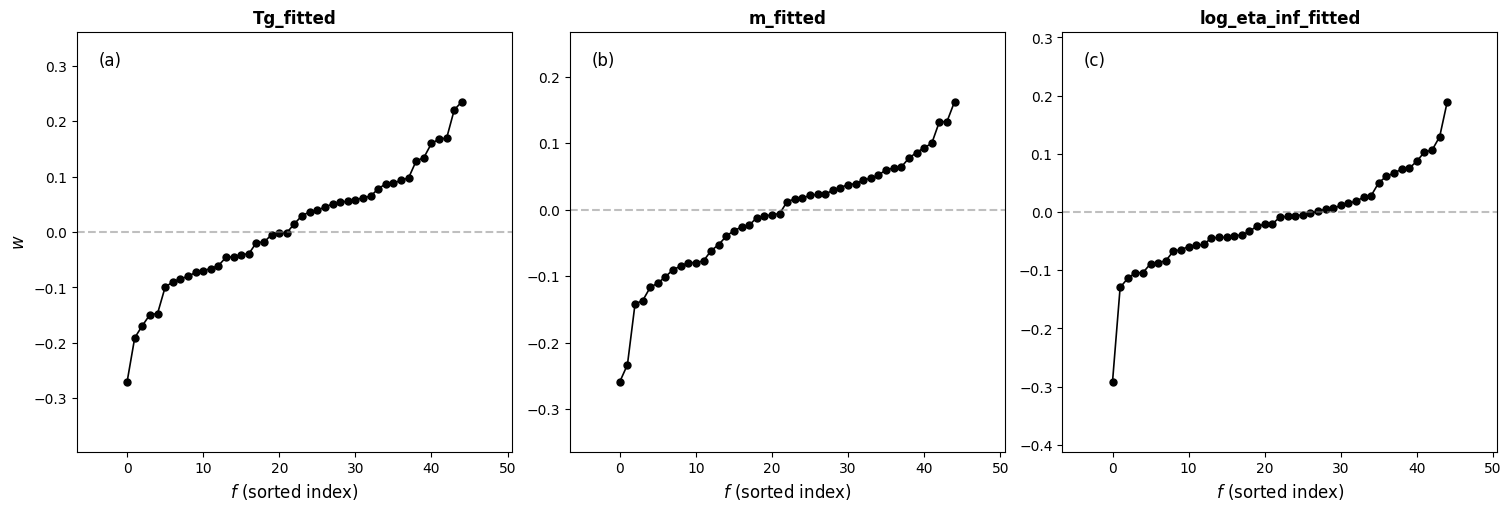

In [98]:
# Feature weights plots (ordered)
importance_data = extract_importance(
    X=X_train_final_standard,
    y=y_train_scaled,
    alpha=0.1,
    n_splits=100,
    sort_by='magnitude' # <- Ordina per il peso più forte, a prescindere dal segno
)

fig_importance = plot_sorted_feature_importance(importance_data, top_n=0)
fig_importance.savefig(plots_path / 'features_importance.pdf', bbox_inches='tight')


importance_data['m_fitted'].head(20)
# print("\nTop 10 features per Tg_fitted:")
# print(importance_data['Tg_fitted'].head(10)[['original_index', 'feature', 'weight', 'abs_weight']])

In [99]:
# Training model

# Instantiate the model with alpha = 0.0
ols_model = CustomRidgeRegression(alpha=0.0, fit_intercept=True)

# Fit the model on the training data
ols_model.fit(X_train_final_standard, y_train_scaled)

pickle.dump(ols_model, open(model_path / "ols_model.pkl", 'wb'))

logger.info("Model successfully trained and saved!")

[INFO] 2026-09-22 12:32:31 - Model successfully trained and saved!


In [100]:
# Evaluating model

target_columns = ['Tg', 'm','log_eta_inf']

evaluation_metrics = evaluate_final_model(
    model=ols_model,
    X_test=X_test_final_standard,
    y_test=y_test_scaled,
    viscosity_df=raw_data,
    target_cols=target_columns,
    y_scaler=y_scaler
)

[INFO] 2026-09-22 12:32:34 - Evaluating model on the unseen Test Set (85 glasses)...

      TEST SET PERFORMANCE (SCALED PARAMETERS)
Target: Tg
  Pearson : 0.906
  R^2     : 0.819
  RMSE    : 0.401
  MAE     : 0.294
  MedAE   : 0.233
--------------------------------------------------
Target: m
  Pearson : 0.875
  R^2     : 0.761
  RMSE    : 0.503
  MAE     : 0.404
  MedAE   : 0.329
--------------------------------------------------
Target: log_eta_inf
  Pearson : 0.459
  R^2     : 0.200
  RMSE    : 0.831
  MAE     : 0.617
  MedAE   : 0.456
--------------------------------------------------
[INFO] 2026-09-22 12:32:34 - Computing global viscosity performance via MYEGA equation...

      VISCOSITY: PREDICTED vs TRUE FITTED (MYEGA)
--------------------------------------------------
  Pearson : 0.913
  R^2     : 0.779
  RMSE    : 1.905
  MAE     : 1.252
  MedAE   : 0.747
      VISCOSITY: PREDICTED vs EXPERIMENTAL (GROUND TRUTH)
--------------------------------------------------
  Pearson : 

[INFO] 2026-09-22 12:32:40 - Rendering 2D density correlation plot with residual inset.


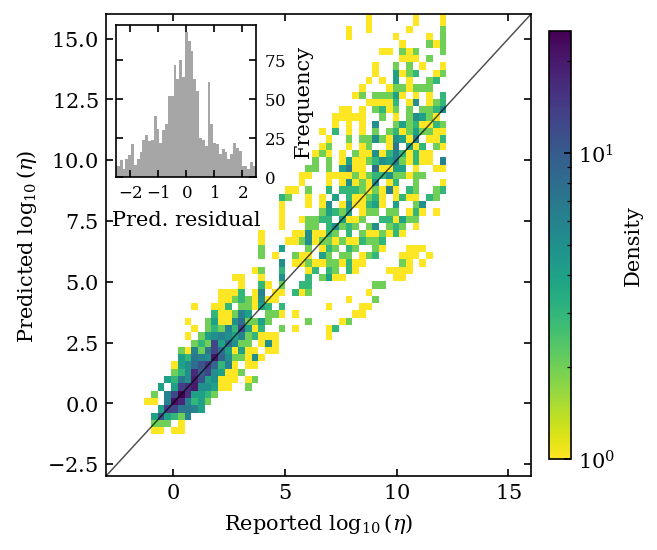

In [101]:
# Cassar density plot

y_true_visc = evaluation_metrics["viscosity_arrays"]["true_experimental"]
y_pred_visc = evaluation_metrics["viscosity_arrays"]["predicted_myega"]

fig_density = plot_viscosity_density_correlation(
    y_true=y_true_visc, 
    y_pred=y_pred_visc
)

fig_density.savefig(plots_path / '2D_density_histogram.pdf', bbox_inches='tight')
fig_density.savefig(plots_path / '2D_density_histogram.png', bbox_inches='tight')

[INFO] 2026-09-22 12:32:51 - Extracting distance and RMSE metrics into a DataFrame.


,ID,Name,Distance,RMSE
0,709,1Al₂O₃.50P₂O₅.18SrO.31ZnO,2.010101,8.199648
1,201,50Na₂O.50P₂O₅,0.100251,4.688676
2,220,74B₂O₃.16BaO.10La₂O₃,1.110106,4.047363
3,51,3Al₂O₃.10B₂O₃.25BaO.6CaO.52SiO₂.5ZnO,1.658671,3.461391
4,428,15Na₂O.27PbO.58SiO₂,0.095810,3.245980
5,141,50B₂O₃.50ZnO,2.000000,3.057315
6,233,7Al₂O₃.11BeO.3K₂O.4Na₂O.76SiO₂,1.227778,3.055000
7,265,15Al₂O₃.65B₂O₃.20CaO,0.151111,2.954775
8,663,67B₂O₃.33BaO,0.022792,2.819555
9,782,8K₂O.28PbO.64SiO₂,0.202300,2.668305


[INFO] 2026-09-22 12:32:52 - Rendering square scatter plot for Extrapolation Distance vs RMSE.


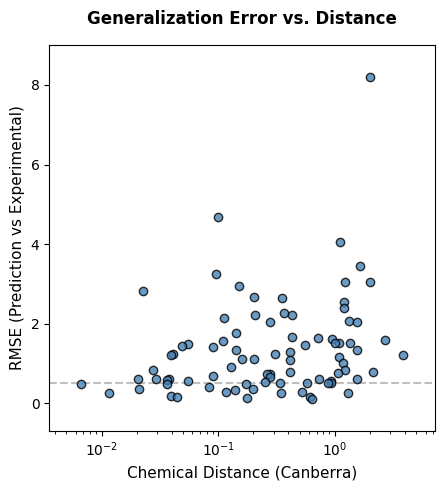

In [102]:
# Test glasses vs performance analysis

# Get glass names
compounds = raw_data.columns[:-3].tolist()
glass_names_dict = generate_glass_names(raw_data, compounds)

# Get model prediction
y_pred_scaled  = ols_model.predict(X_test_final_standard)
y_pred_physical = y_scaler.inverse_transform(y_pred_scaled)

target_columns = ['Tg', 'm','log_inf']

# Prediction dataframe
predictions_df = pd.DataFrame(
    y_pred_physical,
    columns=target_columns,
    index=y_test.index
)

# Generating distance data
metrics_df = generate_extrapolation_metrics(
    compounds=compounds,
    viscosity_df=raw_data,
    predictions_df=predictions_df, 
    names_dict=glass_names_dict
)
display(metrics_df.head(40))

# Generating distance plot
fig_distance = plot_rmse_vs_distance_square(metrics_df)
fig_distance.savefig(plots_path / 'distance_plot.pdf', bbox_inches='tight')

[INFO] 2026-09-22 12:32:57 - Training ensemble of 100 bootstrap models...
[INFO] 2026-09-22 12:32:58 - Rendering bootstrap prediction grids for 85 glasses.


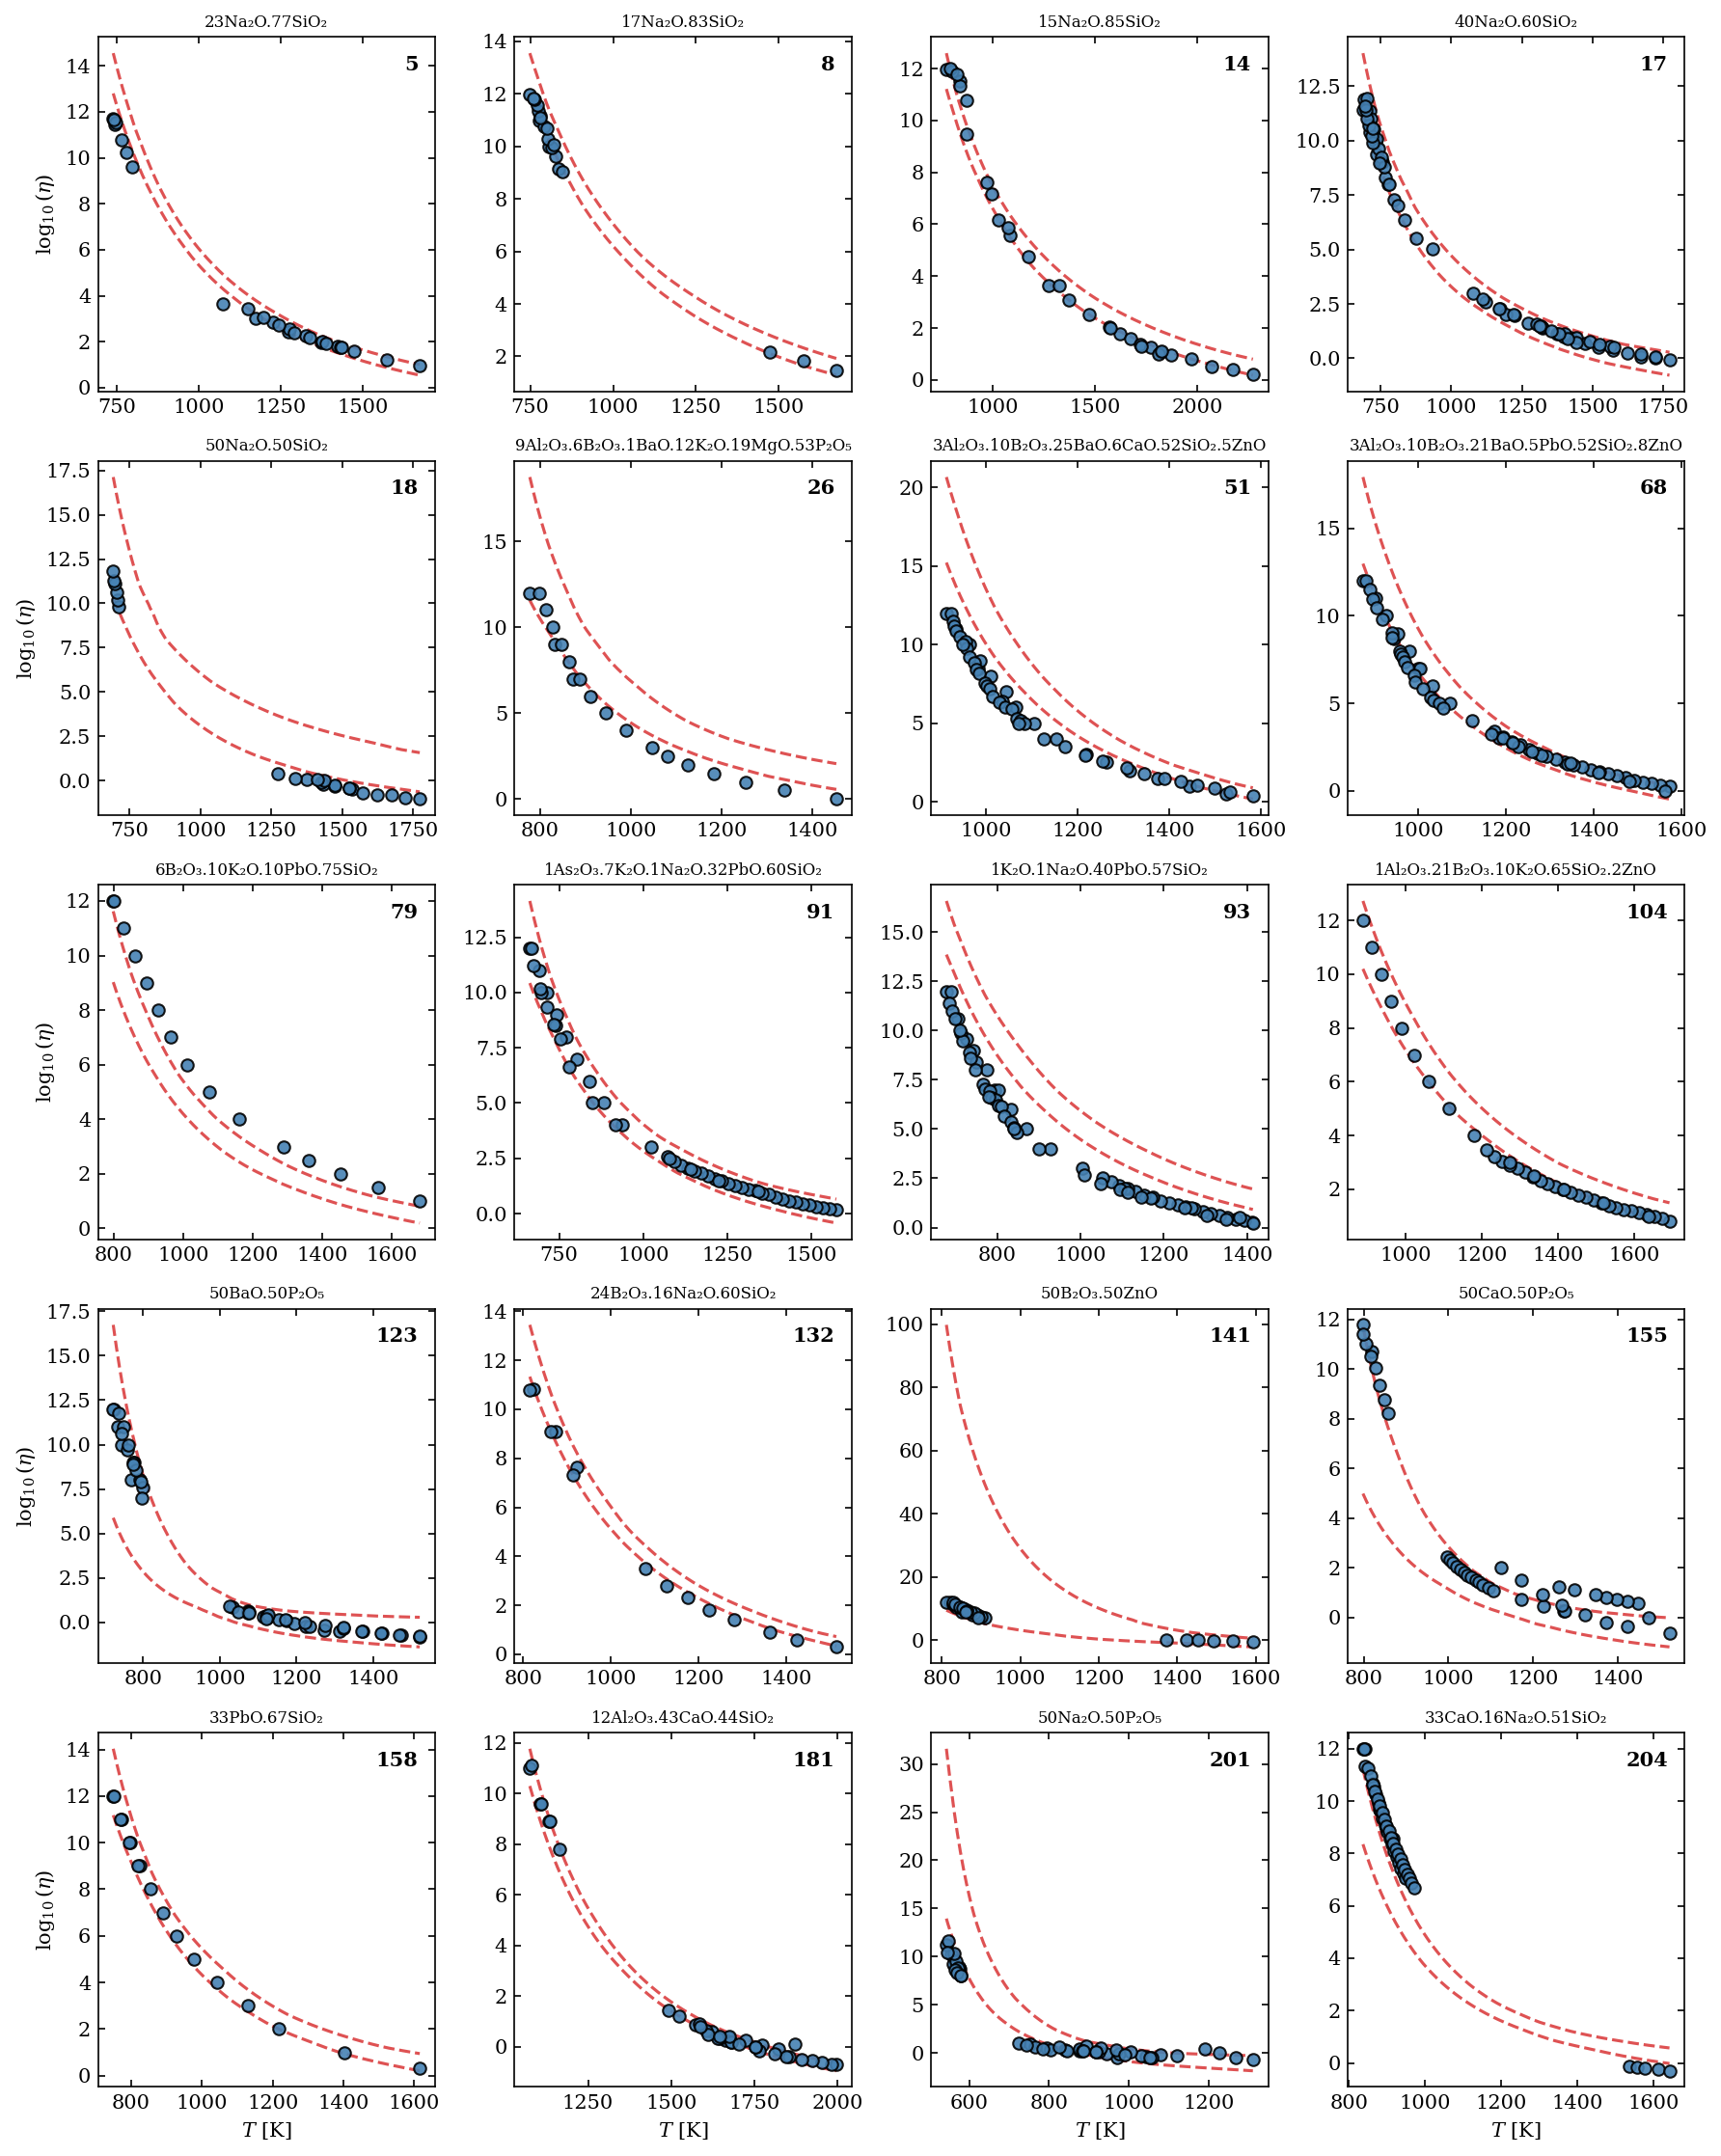

In [103]:
# Plotting test liquids viscosities with uncertainty bars

ols_ridge = CustomRidgeRegression(alpha=0.0, fit_intercept=True)

predictions_df, distributions_dict = generate_bootstrap_predictions(
    base_model=ols_ridge,
    X_train=X_train_final_standard,
    y_train=y_train_scaled,
    X_test=X_test_final_standard,
    y_scaler=y_scaler,
    n_estimators=100
)

viscosity_plots_path = plots_path / "test_viscosity_plots"
viscosity_plots_path.mkdir(parents=True, exist_ok=True)

plot_viscosity_grids_bootstrap(
    viscosity_df=raw_data,
    distributions_dict=distributions_dict,
    names_dict=glass_names_dict,
    save_dir=viscosity_plots_path,
    confidence=95.0
)